In [17]:
import os
import sys

from copy import deepcopy

In [18]:
path_this = os.path.dirname(os.path.abspath(__name__))
path_root= os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

In [30]:
import pandas as pd

df_dataset = pd.read_csv(os.path.join(path_dataset,'raw_dataset.csv'))
# df_backup = deepcopy(df_dataset)
df_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
columns_desc = {
	"categorical": ['gender', 'MultipleLines', 'InternetService', 
				 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
				 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'],
	"numeric": ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
	"bool_cat": ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
}

feature_desc = {
	"categorical": [
		# Membership Details
		'customerID', 'Contract', 'PaymentMethod', 'PaperlessBilling',
		# Demograph
		'gender', 'SeniorCitizen', 'Partner', 'Dependents',
		# Service
		'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
		'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService',
		# target 
		'Churn'],
	"numeric": ['tenure', 'MonthlyCharges', 'TotalCharges']
}

In [27]:
def preprocess_churn_col(value:str):
	if isinstance(value, int):
		return value
	elif value.lower() == 'yes':
		return 1
	elif value.lower() == 'no':
		return 0

def preprocess_senior_citizen(value):
	if str(value) == '0':
		return 'No'
	elif str(value) == '1':
		return 'Yes'
	else:
		return str(value)

In [ ]:
df_dataset['Churn'] = df_dataset['Churn'].map(preprocess_churn_col)
df_dataset['SeniorCitizen'] = df_dataset['SeniorCitizen'].map(preprocess_senior_citizen)

# from dataset description, we found the "TotalCharges" should be numeric
df_dataset['TotalCharges'] = pd.to_numeric(df_dataset['TotalCharges'], errors='coerce')
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df_dataset.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# df_dataset.loc[df_dataset['tenure'] == 0].reset_index(drop=True)
df_dataset.loc[df_dataset['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


In [34]:
df_dataset.describe()

,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,0.265370
std,24.559481,30.090047,2266.771362,0.441561
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [38]:
df_dataset = df_dataset.loc[df_dataset['tenure'] != 0].reset_index(drop=True)
df_dataset.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   object 
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [ ]:
def string_standarization(text):
	text = text.lower().strip()
	return text

In [49]:
cat_columns = df_dataset.select_dtypes(include=object).columns
for col in cat_columns:
	df_dataset[col] = df_dataset[col].map(lambda x: x.lower().strip())

In [47]:
df_dataset.select_dtypes(exclude=object).shape

(7032, 4)

In [10]:
# numerical_col = df_dataset.select_dtypes(include='number').columns.tolist()
# categorical_col = df_dataset.select_dtypes(include='object').columns.tolist()
# print(numerical_col, categorical_col)

In [40]:
df_dataset.InternetService.value_counts(dropna=False)

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [41]:
df_dataset.PhoneService.value_counts()

PhoneService
Yes    6352
No      680
Name: count, dtype: int64

In [42]:
# df_dataset.loc[df_dataset['Churn']==1].value_counts(subset=['InternetService', 'PhoneService'], normalize=True, dropna=False).reset_index()
df_dataset.value_counts(subset=['InternetService', 'TechSupport'], normalize=True, dropna=False).reset_index()

,InternetService,TechSupport,proportion
0,Fiber optic,No,0.317122
1,No,No internet service,0.216155
2,DSL,No,0.176621
3,DSL,Yes,0.166951
4,Fiber optic,Yes,0.123151


In [16]:
def calculate_service(row):
	score = 0
	if row.get('PhoneService') == 'Yes':
		score += 5
	if row.get('InternetService') != 'No':
		score += 10
	
	internet_add_ons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
	for add_on in internet_add_ons:
		if row.get(add_on) == 'Yes':
			score += 1

	if row.get('MultipleLines') == 'Yes':
		score += 1
	return score

In [17]:
df_dataset['ServiceScore'] = df_dataset.apply(calculate_service, axis=1)
df_dataset.loc[:, ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
				   'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'ServiceScore']]

,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceScore
0,No,No phone service,DSL,No,Yes,No,No,No,No,11
1,Yes,No,DSL,Yes,No,Yes,No,No,No,17
2,Yes,No,DSL,Yes,Yes,No,No,No,No,17
3,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,13
4,Yes,No,Fiber optic,No,No,No,No,No,No,15
...,...,...,...,...,...,...,...,...,...,...
7027,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,21
7028,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,20
7029,No,No phone service,DSL,Yes,No,No,No,No,No,11
7030,Yes,Yes,Fiber optic,No,No,No,No,No,No,16


In [51]:
df_dataset.to_csv(
	os.path.join(path_dataset, 'preprocessed_dataset.csv'), index=False)

In [21]:
df_dataset.loc[df_dataset['InternetService']=='No', 'ServiceScore'].describe()

count    1520.000000
mean        5.223684
std         0.416850
min         5.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         6.000000
Name: ServiceScore, dtype: float64

## Visualize the data

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
churn_and_gender = df_dataset.value_counts(subset=['Churn', 'gender']).reset_index()
churn_and_gender['percentage'] = churn_and_gender['count'].map(lambda x: round((x / churn_and_gender['count'].sum()) * 100, 2))
# churn_and_gender['label'] = churn_and_gender['gender'] + ' ' + churn_and_gender['Churn'] + '\n' + churn_and_gender['percentage']
churn_and_gender['label'] = churn_and_gender.apply(lambda x: f"{x['gender']}\n{x['percentage']}% ({x['count']})", axis=1)
churn_and_gender['color'] = churn_and_gender['gender'].map(
	lambda gender: '#347DC1' if gender.lower() == 'male' else '#CC6594')
churn_and_gender

,Churn,gender,count,percentage,label,color
0,0,Male,2619,37.24,Male\n37.24% (2619),#347DC1
1,0,Female,2544,36.18,Female\n36.18% (2544),#CC6594
2,1,Female,939,13.35,Female\n13.35% (939),#CC6594
3,1,Male,930,13.23,Male\n13.23% (930),#347DC1


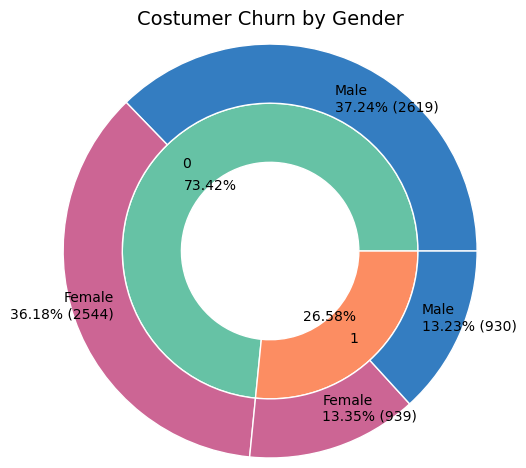

In [35]:
# Use Seaborn palettes for styling
colors_inner = sns.color_palette("Set2", churn_and_gender['Churn'].nunique())
# colors_outer = sns.color_palette("Pastel2", churn_and_gender.shape[0])

# display(colors_inner, colors_outer)
fig, ax = plt.subplots()
# setup inner pie
ax.pie(
	churn_and_gender.groupby('Churn')['count'].sum(),
	labels=churn_and_gender['Churn'].unique(),
	labeldistance=0.8, autopct='%1.2f%%',
	colors=colors_inner, radius=1.0,
	wedgeprops={'width':0.4, 'edgecolor':'w'})
# setup outer pie
ax.pie(
	churn_and_gender['count'], radius=1.4,
	labels=churn_and_gender['label'],
	labeldistance=0.8, 
	colors=churn_and_gender['color'],
	wedgeprops={'width':0.4, 'edgecolor':'w'})
# ax.tick_params(axis='both', labelsize=12, labelcolor='blue', rotation=45)
plt.title("Costumer Churn by Gender", fontsize=14, pad=30)
plt.show()

In [134]:
df_dataset.select_dtypes(include='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

,Churn,Contract,customerID
0,0,Month-to-month,2220
1,0,One year,1306
2,0,Two year,1637
3,1,Month-to-month,1655
4,1,One year,166
5,1,Two year,48


<Axes: xlabel='Churn', ylabel='customerID'>

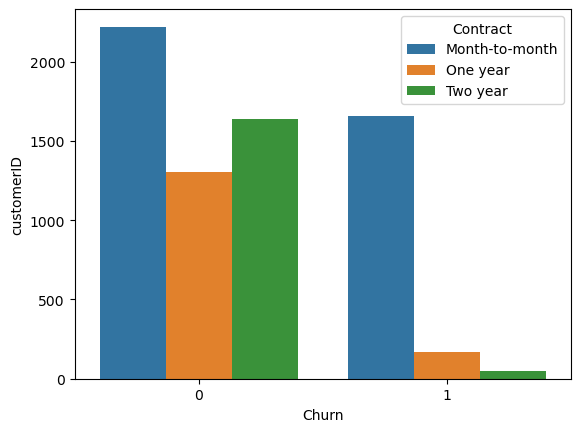

In [36]:
churn_vs_contract = df_dataset.groupby(['Churn', 'Contract'])['customerID'].count().reset_index()
display(churn_vs_contract)
sns.barplot(data=churn_vs_contract, x='Churn', y='customerID', hue='Contract')

In [37]:
tenure_vs_monthlyrate = df_dataset.loc[:, ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
display(tenure_vs_monthlyrate)

,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1
...,...,...,...,...
7027,24,84.80,1990.50,0
7028,72,103.20,7362.90,0
7029,11,29.60,346.45,0
7030,4,74.40,306.60,1


<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

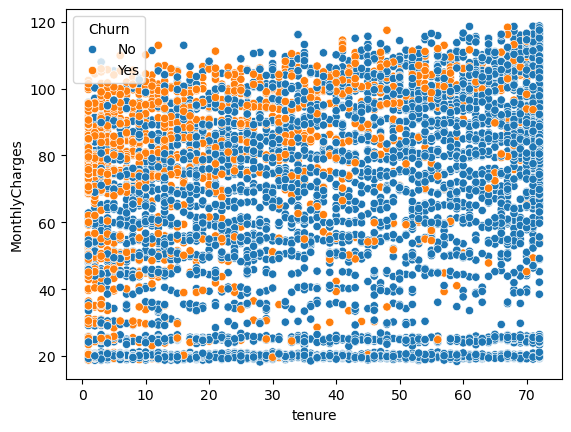

In [137]:
sns.scatterplot(data=tenure_vs_monthlyrate, x='tenure', y='MonthlyCharges', hue='Churn')

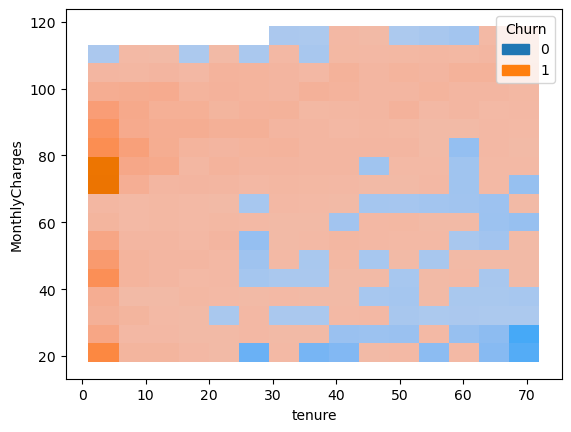

In [39]:
# np.ceil(round(df_dataset['TotalCharges'] / df_dataset['MonthlyCharges'], 2))
sns.histplot(data=tenure_vs_monthlyrate, x='tenure', y='MonthlyCharges', hue='Churn')
plt.show()

In [41]:
df_dataset.loc[df_dataset['MonthlyCharges'].notna(), ['MonthlyCharges', 'Churn']]

,MonthlyCharges,Churn
0,29.85,0
1,56.95,0
2,53.85,1
3,42.30,0
4,70.70,1
...,...,...
7027,84.80,0
7028,103.20,0
7029,29.60,0
7030,74.40,1


<Axes: xlabel='Churn', ylabel='tenure'>

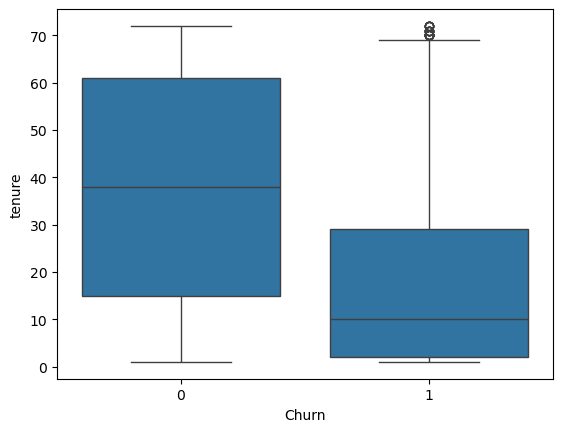

In [42]:
display(sns.boxplot(tenure_vs_monthlyrate, x='Churn', y='tenure'))

Text(0.5, 1.0, 'Monthly Charges by Churn')

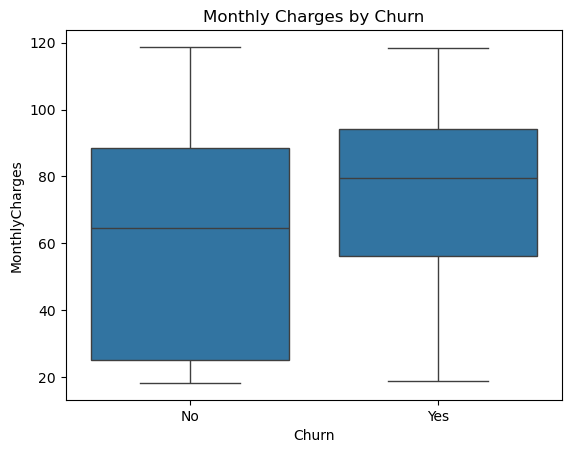

In [142]:
sns.boxplot(tenure_vs_monthlyrate, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges by Churn")

In [143]:
display(df_dataset.groupby('Churn')['tenure'].describe())
display(df_dataset.groupby('Churn')['MonthlyCharges'].describe())

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


In [144]:
df_dataset['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='tenure', ylabel='TotalCharges'>

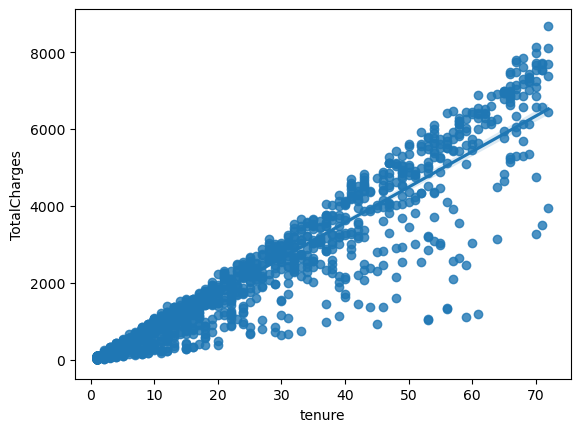

In [145]:
sns.regplot(data=df_dataset.loc[df_dataset['Churn'] == 'Yes'], x='tenure', y='TotalCharges')

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

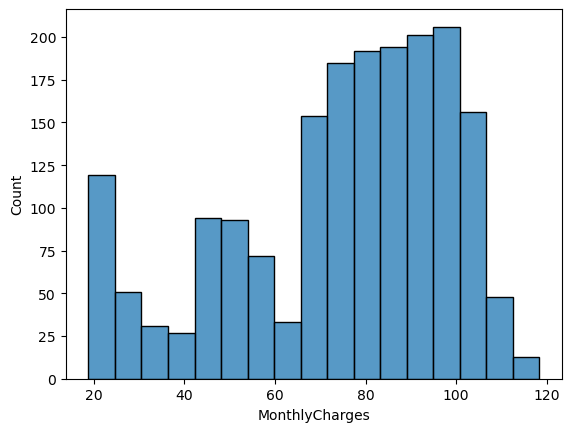

In [146]:
# sns.kdeplot(data=tenure_vs_monthlyrate, x='MonthlyCharges', hue='Churn', fill=True)
# sns.histplot(data=tenure_vs_monthlyrate, x='MonthlyCharges', hue='Churn')
sns.histplot(data=df_dataset.loc[df_dataset['Churn'] == 'Yes'], x='MonthlyCharges')

<Axes: xlabel='TotalCharges', ylabel='Density'>

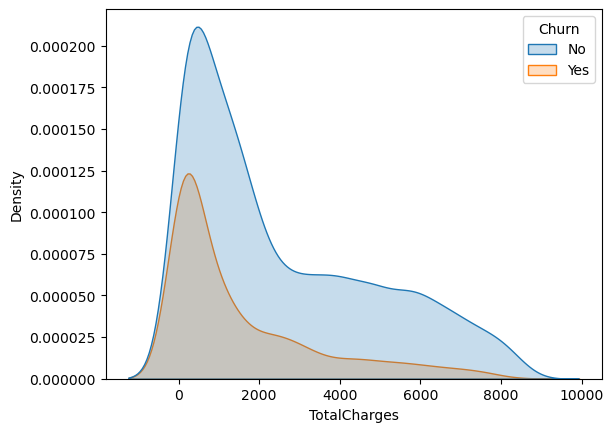

In [338]:
sns.kdeplot(data=tenure_vs_monthlyrate, x='TotalCharges', hue='Churn', fill=True)
# sns.histplot(data=tenure_vs_monthlyrate, x='TotalCharges', hue='Churn')
# sns.histplot(data=df_dataset.loc[df_dataset['Churn'] == 'Yes'], x='TotalCharges')

In [340]:
tenure_vs_monthlyrate

,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,No
1,34,56.95,1889.50,No
2,2,53.85,108.15,Yes
3,45,42.30,1840.75,No
4,2,70.70,151.65,Yes
...,...,...,...,...
7027,24,84.80,1990.50,No
7028,72,103.20,7362.90,No
7029,11,29.60,346.45,No
7030,4,74.40,306.60,Yes


<Axes: xlabel='tenure', ylabel='MonthlyCharges'>

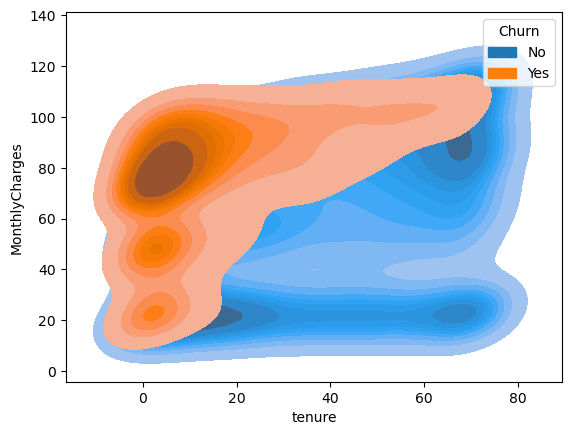

In [342]:
sns.kdeplot(data=tenure_vs_monthlyrate, x='tenure', y='MonthlyCharges', hue='Churn', fill=True)
# sns.histplot(data=tenure_vs_monthlyrate, x='tenure', hue='Churn')
# sns.histplot(data=df_dataset.loc[df_dataset['Churn'] == 'Yes'], x='tenure')

Text(0.5, 1.0, 'Contract Period vs Tenure')

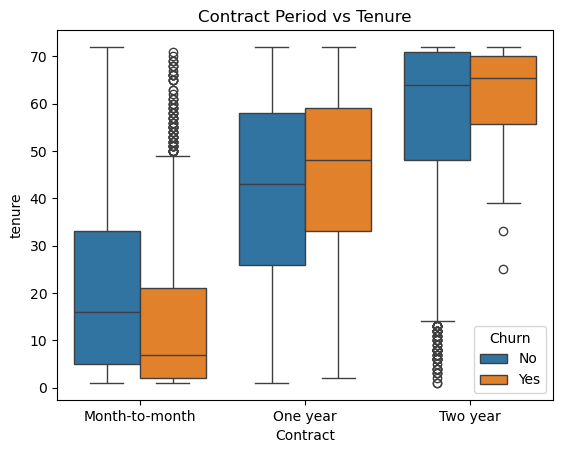

In [149]:
sns.boxplot(df_dataset, x='Contract', y='tenure', hue='Churn')
plt.title('Contract Period vs Tenure')

In [150]:
df_dataset.groupby(['Contract', 'Churn'])['tenure'].describe().reset_index()

,Contract,Churn,count,mean,std,min,25%,50%,75%,max
0,Month-to-month,No,2220.0,21.033333,18.398051,1.0,5.00,16.0,33.0,72.0
1,Month-to-month,Yes,1655.0,14.016918,15.828615,1.0,2.00,7.0,21.0,71.0
2,One year,No,1306.0,41.705972,19.066431,1.0,26.00,43.0,58.0,72.0
3,One year,Yes,166.0,44.963855,18.367261,2.0,33.00,48.0,59.0,72.0
4,Two year,No,1637.0,56.948687,17.875481,1.0,48.00,64.0,71.0,72.0
5,Two year,Yes,48.0,61.270833,11.004331,25.0,55.75,65.5,70.0,72.0


In [151]:
df_dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: xlabel='PaymentMethod', ylabel='MonthlyCharges'>

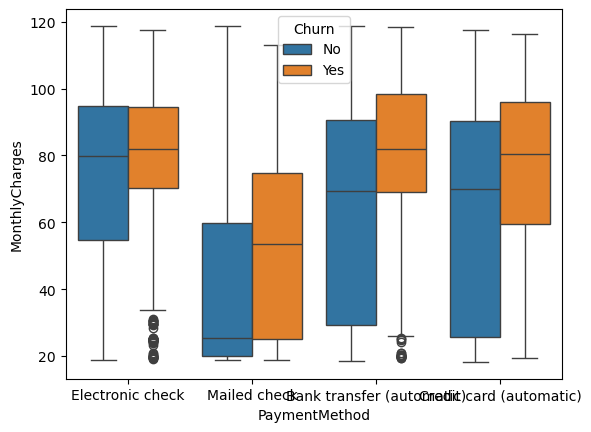

In [ ]:
sns.boxplot(df_dataset, x='PaymentMethod', y='MonthlyCharges', hue='Churn')
plt.show()

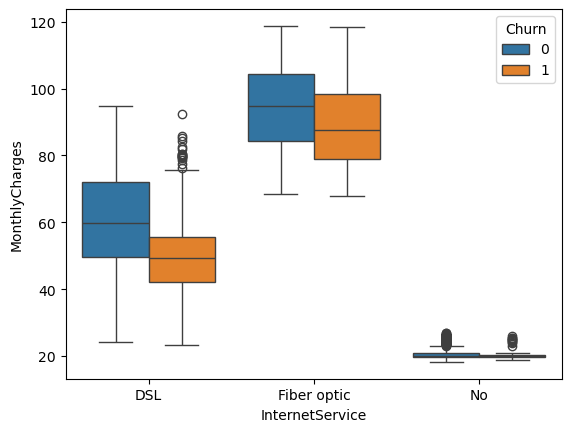

In [44]:
sns.boxplot(df_dataset, x='InternetService', y='MonthlyCharges', hue='Churn')
plt.show()

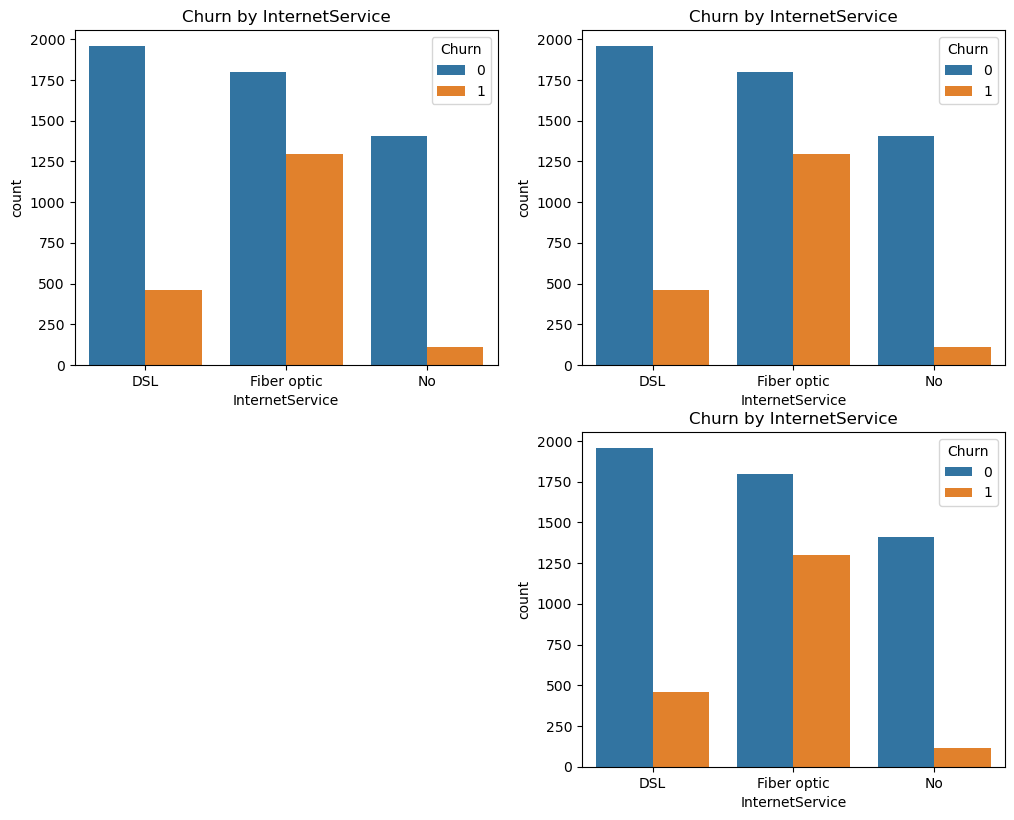

In [63]:
fig = plt.figure(figsize = (12, 20))
ax = fig.add_subplot(4, 2, 1)
ax = sns.countplot(data=df_dataset, x='InternetService', hue='Churn')#, palette="Blues")
ax.set_title('Churn by InternetService')

ax = fig.add_subplot(4, 2, 2)
ax = sns.countplot(data=df_dataset, x='InternetService', hue='Churn')#, palette="Blues")
ax.set_title('Churn by InternetService')

# ax = fig.add_subplot(4, 2, 3)
# ax = sns.countplot(data=df_dataset, x='InternetService', hue='Churn')#, palette="Blues")
# ax.set_title('Churn by InternetService')

ax = fig.add_subplot(4, 2, 4)
ax = sns.countplot(data=df_dataset, x='InternetService', hue='Churn')#, palette="Blues")
ax.set_title('Churn by InternetService')

plt.show()

In [43]:
df_dataset['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [353]:
df_dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [372]:
df_dataset.loc[df_dataset['PaymentMethod'] == 'Mailed check'].value_counts(['Churn', 'PhoneService'])#.groupby('Churn')['tenure'].describe()

Churn  PhoneService
No     Yes             1171
Yes    Yes              274
No     No               125
Yes    No                34
Name: count, dtype: int64

In [373]:
service_columns = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV']
for col in service_columns:
	display(df_dataset.loc[
		(df_dataset['Churn'] == 'Yes') & (df_dataset['PaymentMethod'] == 'Mailed check'), col].value_counts())

PhoneService
Yes    274
No      34
Name: count, dtype: int64

MultipleLines
No                  206
Yes                  68
No phone service     34
Name: count, dtype: int64

InternetService
DSL            127
Fiber optic    110
No              71
Name: count, dtype: int64

OnlineSecurity
No                     196
No internet service     71
Yes                     41
Name: count, dtype: int64

OnlineBackup
No                     185
No internet service     71
Yes                     52
Name: count, dtype: int64

DeviceProtection
No                     180
No internet service     71
Yes                     57
Name: count, dtype: int64

TechSupport
No                     186
No internet service     71
Yes                     51
Name: count, dtype: int64

StreamingTV
No                     168
No internet service     71
Yes                     69
Name: count, dtype: int64

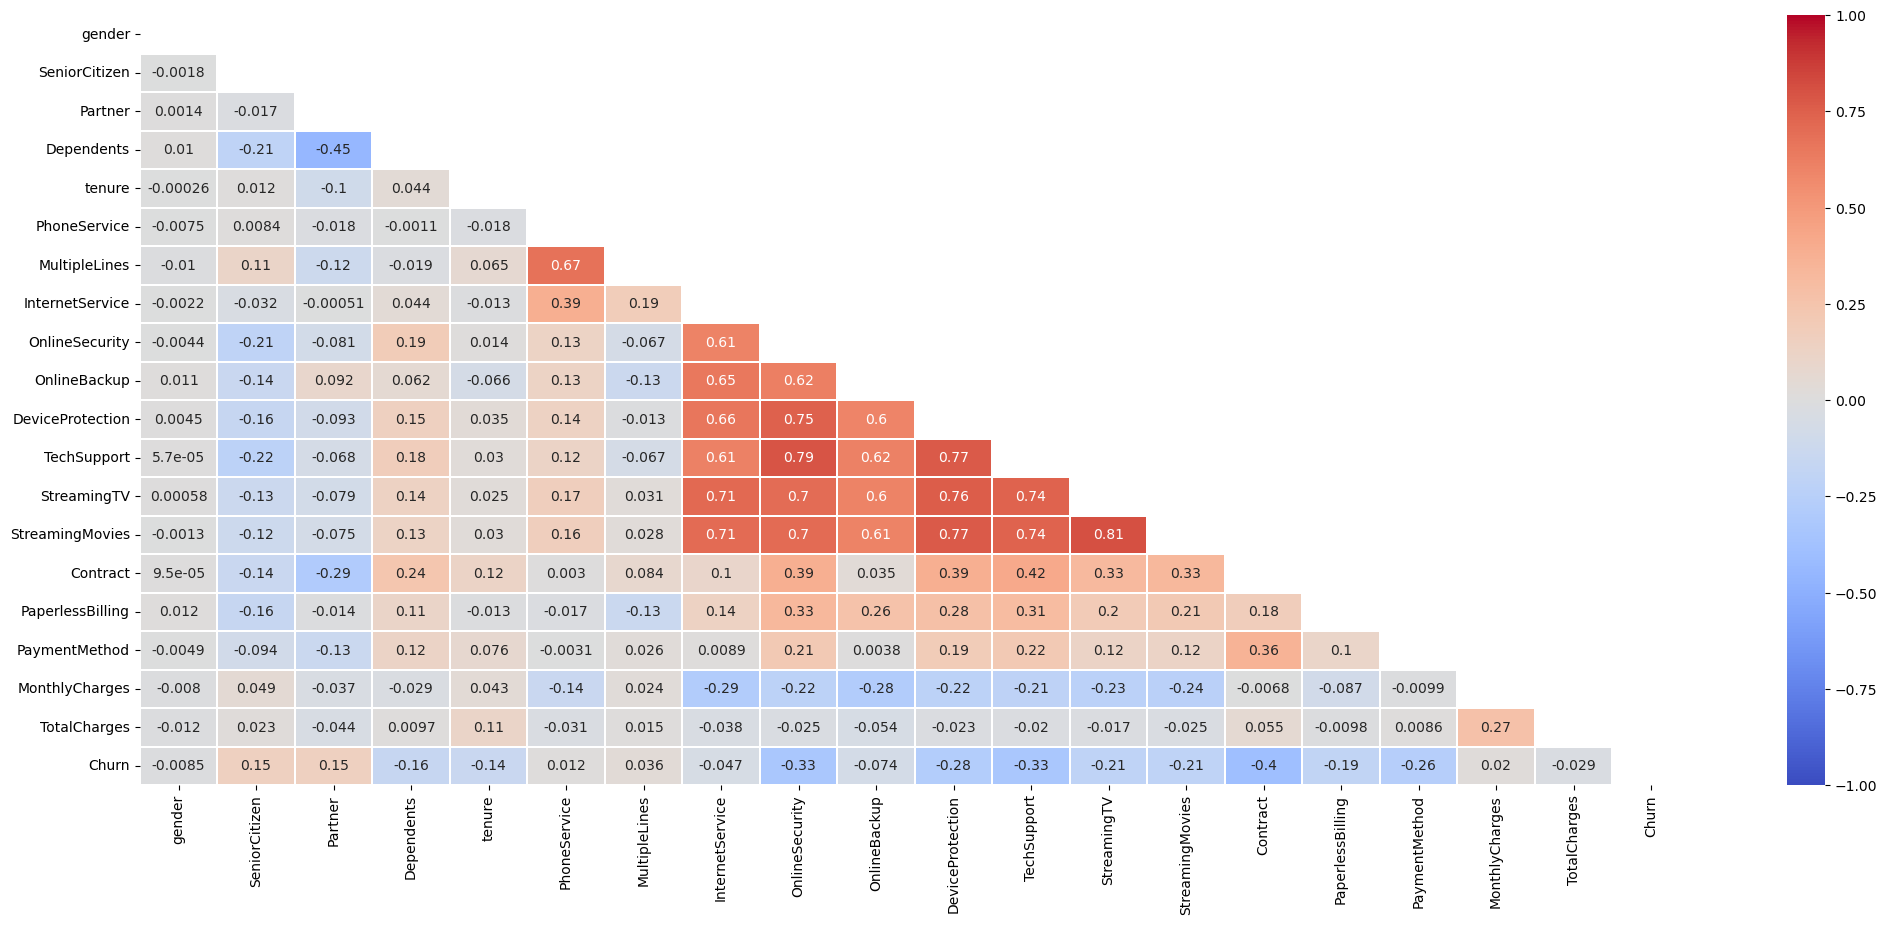

In [153]:
# df_dataset.corr()
plt.figure(figsize=(25, 10))
corr = df_dataset.drop(columns=['customerID']).apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

<Axes: >

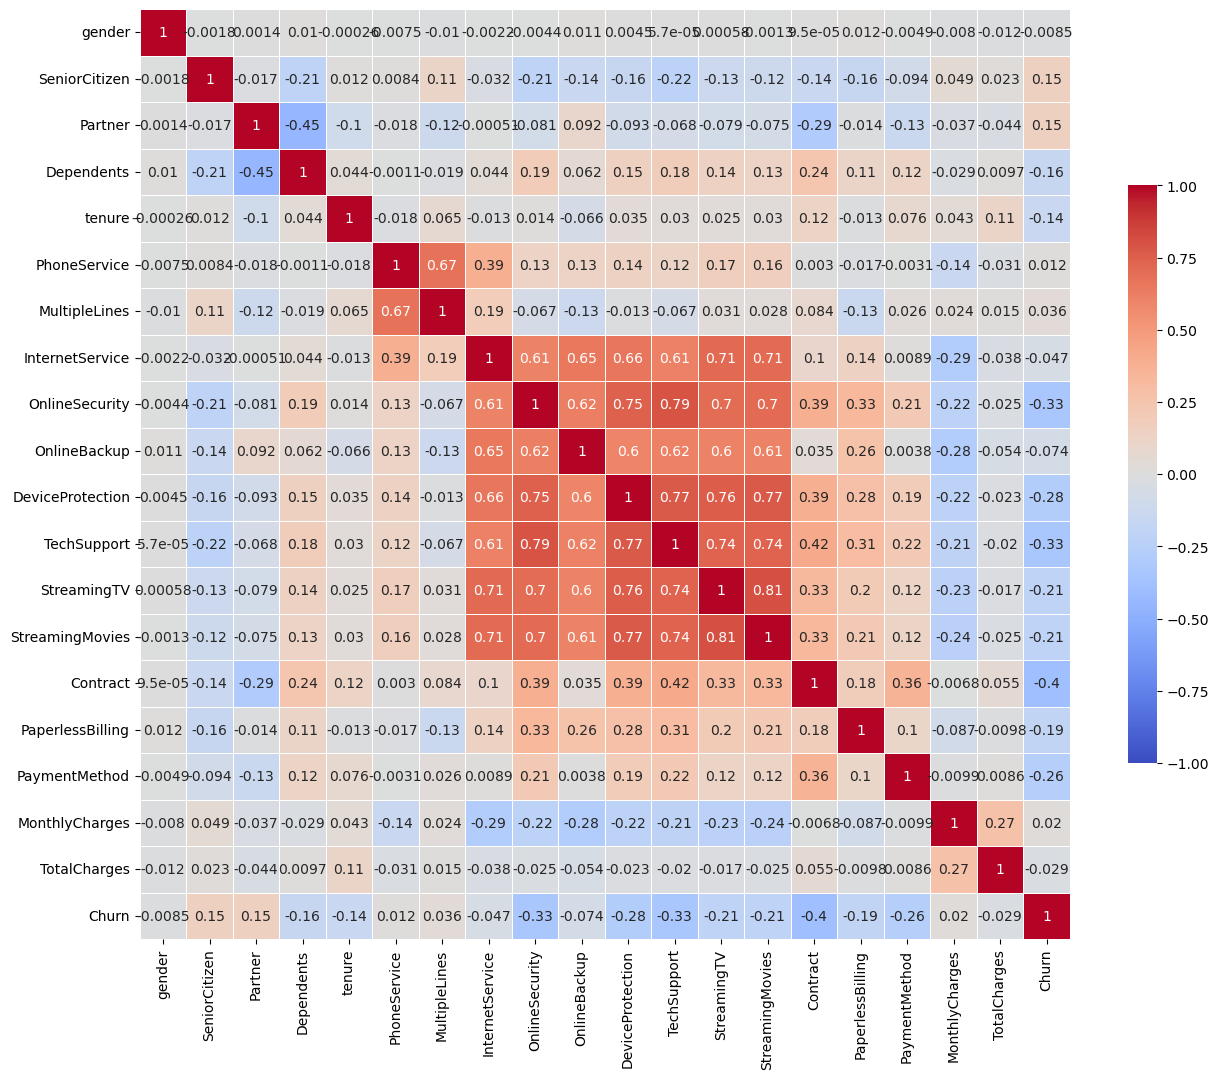

In [154]:
fig, ax = plt.subplots(figsize=(15,15))
corr = df_dataset.drop(columns=['customerID']).apply(lambda x: pd.factorize(x)[0]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})


In [39]:
corr['Churn'].sort_values(ascending=False)

Churn               1.000000
SeniorCitizen       0.150541
Partner             0.149982
MultipleLines       0.036148
MonthlyCharges      0.020303
PhoneService        0.011691
gender             -0.008545
TotalCharges       -0.028994
InternetService    -0.047097
OnlineBackup       -0.073934
tenure             -0.143101
Dependents         -0.163128
PaperlessBilling   -0.191454
StreamingTV        -0.205246
StreamingMovies    -0.207150
PaymentMethod      -0.262918
DeviceProtection   -0.281048
TechSupport        -0.329474
OnlineSecurity     -0.332443
Contract           -0.396150
Name: Churn, dtype: float64

# Modelling

In [203]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

scaler = StandardScaler()

## Logistic Regression

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


In [156]:
# df_dataset['churn_int'] = df_dataset['Churn'].map(lambda x: 1 if x == 'Yes' else 0)
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [43]:
# df_dataset = df_dataset.replace({'Yes': 1, 'No': 0})
# df_dataset['gender'] = df_dataset['gender'].replace({'Male': 0, 'Female': 1})

In [157]:
numeric_col = df_dataset.select_dtypes(include='number').columns.tolist()
categorical_col = df_dataset.select_dtypes(include='object').columns.tolist()

df_dataset[categorical_col].head()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [207]:
df_logreg = deepcopy(df_dataset)

In [377]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # Use sparse_output for newer sklearn versions
df_logreg_encoded = encoder.fit_transform(df_logreg.loc[:, columns_desc['categorical']])
df_logreg_encoded = pd.DataFrame(df_logreg_encoded, columns=encoder.get_feature_names_out(columns_desc['categorical']))
# display(df_logreg_encoded.shape)
scaler = StandardScaler()
df_logreg_numeric = scaler.fit_transform(df_dataset.loc[:, columns_desc['numeric']])
df_logreg_numeric = pd.DataFrame(df_logreg_numeric, columns=scaler.get_feature_names_out(columns_desc['numeric']))
# display(df_logreg_numeric.shape)

df_logreg_bool = df_dataset.loc[:, columns_desc['bool_cat']].replace({'Yes': 1.0, 'No': 0.0})
# df_logreg_bool = pd.DataFrame()
# for col in columns_desc['bool_cat']:
# 	df_logreg_bool[col] = df_dataset[col].map({'Yes': 1, 'No': 0})
# display(df_logreg_bool.shape)

df_norm_dataset = pd.concat([df_logreg_numeric, df_logreg_bool, df_logreg_encoded], axis=1)#.drop(columns='tenure')
df_norm_dataset.head()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_47660\1381887938.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_logreg_bool = df_dataset.loc[:, columns_desc['bool_cat']].replace({'Yes': 1.0, 'No': 0.0})


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender_Female,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.440327,-1.280248,-1.161694,-0.994194,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.440327,0.064303,-0.260878,-0.173740,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.440327,-1.239504,-0.363923,-0.959649,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.440327,0.512486,-0.747850,-0.195248,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.440327,-1.239504,0.196178,-0.940457,0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [378]:
X = df_norm_dataset.drop(columns=['Churn'])
# X_norm = StandardScaler().fit_transform(X)
Y = df_norm_dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# ===================
# for col in columns_desc['bool_cat']:
# 	df_logreg[col] = LabelBinarizer().fit_transform(df_logreg[col])
# df_logreg.loc[:, columns_desc['bool_cat']]
# X = df_norm_dataset.drop(columns=['customerID', 'Churn'])
# # X_norm = StandardScaler().fit_transform(X)
# Y = df_norm_dataset['Churn']

# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [379]:
LR = LogisticRegression().fit(X_train, y_train)
yhat = LR.predict(X_test)
# print(yhat[:10])

yhat_prob = LR.predict_proba(X_test)
# print(yhat_prob[:10])

print(log_loss(y_test, yhat_prob))
print(classification_report(y_true=y_test, y_pred=yhat))

0.4275860924171763
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1033
         1.0       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [380]:
confusion_matrix(y_true=y_test, y_pred=yhat)

array([[916, 117],
       [159, 215]])

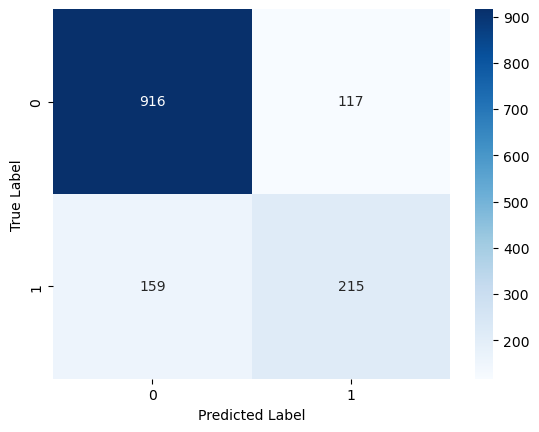

In [381]:
sns.heatmap(
	confusion_matrix(y_true=y_test, y_pred=yhat), 
	annot=True, fmt = "d", cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [384]:
round(916 / (916+159), 2)

0.85

In [182]:
yhat_prob[:10]
# y_test[:10].to_list()

array([[0.947201  , 0.052799  ],
       [0.3884717 , 0.6115283 ],
       [0.99193691, 0.00806309],
       [0.81499616, 0.18500384],
       [0.88187891, 0.11812109],
       [0.80572688, 0.19427312],
       [0.9762961 , 0.0237039 ],
       [0.85801735, 0.14198265],
       [0.50844351, 0.49155649],
       [0.94988782, 0.05011218]])

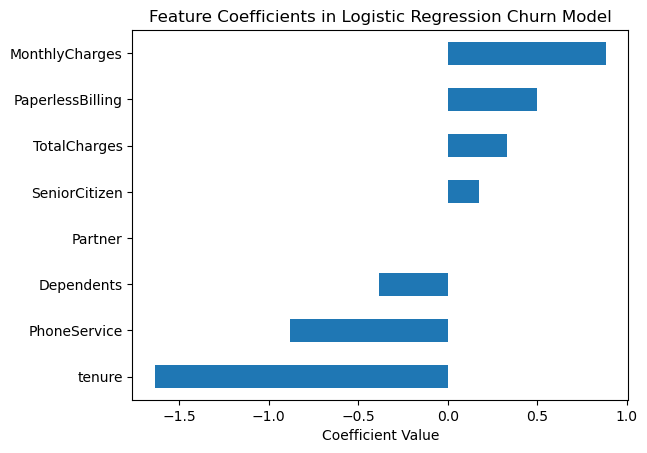

In [183]:
coefficients = pd.Series(LR.coef_[0], index=df_norm_dataset.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

In [184]:
LR.score(X_test, y_test)

0.7839374555792467

---

In [476]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
	roc_curve,
    log_loss,
    confusion_matrix,
    classification_report
)

In [477]:
df_logreg = deepcopy(df_dataset)
df_logreg['Churn'] = df_logreg['Churn'].map({'Yes': 1, 'No': 0})
df_logreg.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [478]:
X = df_logreg.drop(columns=['customerID', 'Churn', 'TotalCharges'])
	# 'SeniorCitizen', 'gender', 'PaperlessBilling', 'customerID', 'Churn',
	# 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
	# 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 
	# 'Partner', 'Dependents', 'PhoneService'
	# ])
y = df_logreg['Churn']

In [479]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [480]:
numeric_features = ['tenure', 'MonthlyCharges']
categorical_features = [
	'SeniorCitizen', 'gender', 'PaperlessBilling', 
	'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
	'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 
	'Partner', 'Dependents', 'PhoneService']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)


In [481]:
# log_reg = LogisticRegression(
#     l1_ratio=0,
#     solver="liblinear",
#     max_iter=1000,
# 	class_weight=None,
# 	C=10
# )
log_reg = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
    max_iter=1000
)
# {'model__C': 10, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", log_reg)
    ]
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [482]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)
# y_pred = (y_proba >= 0.35).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8031272210376688
Precision: 0.6456456456456456
Recall: 0.5748663101604278
F1 Score: 0.6082036775106082
ROC AUC: 0.833615035383158
Log Loss: 0.42944813816514177

Confusion Matrix:
 [[915 118]
 [159 215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [484]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
# y_pred = pipeline.predict(X_test)
y_pred = (y_proba >= 0.35).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7704335465529495
Precision: 0.553014553014553
Recall: 0.7112299465240641
F1 Score: 0.6222222222222222
ROC AUC: 0.833615035383158
Log Loss: 0.42944813816514177

Confusion Matrix:
 [[818 215]
 [108 266]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.84      1033
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



### Find the best threshold

In [502]:
import numpy as np

thresholds = np.linspace(0.1, 0.5, 50)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.33673469387755106), 0.6252873563218391)

In [492]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
# y_pred = pipeline.predict(X_test)
# y_pred = (y_proba >= 0.35).astype(int)
y_pred = (y_proba >= best_t).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7683013503909026
Precision: 0.5483870967741935
Recall: 0.7272727272727273
F1 Score: 0.6252873563218391
ROC AUC: 0.833615035383158
Log Loss: 0.42944813816514177

Confusion Matrix:
 [[809 224]
 [102 272]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



### Find the best param

In [493]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 2, 3, 4, 5, 10, 100],
    "model__l1_ratio": [0, 1],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear"]  # needed for l1
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [494]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)


Best parameters: {'model__C': 10, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}


In [503]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
# y_pred = pipeline.predict(X_test)
# y_pred = (y_proba >= 0.35).astype(int)
y_pred = (y_proba >= best_t).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7683013503909026
Precision: 0.5483870967741935
Recall: 0.7272727272727273
F1 Score: 0.6252873563218391
ROC AUC: 0.833615035383158
Log Loss: 0.42944813816514177

Confusion Matrix:
 [[809 224]
 [102 272]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [449]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    best_model,
    # method="isotonic",  # or "sigmoid" if data is small
    method="sigmoid",  # or "sigmoid" if data is small
    cv=3
)

calibrated_model.fit(X_train, y_train)


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...liblinear'))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [453]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]
# y_pred = pipeline.predict(X_test)
y_pred = (y_proba >= 0.35).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7690120824449183
Precision: 0.5505154639175258
Recall: 0.713903743315508
F1 Score: 0.6216530849825378
ROC AUC: 0.8328566399718386
Log Loss: 0.43042109073540424

Confusion Matrix:
 [[815 218]
 [107 267]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [473]:
result = []

for index, model in zip(['pipeline', 'best_model', 'calibrated'], [pipeline, best_model, calibrated_model]):
	y_proba = model.predict_proba(X_test)[:, 1]
	# y_pred = pipeline.predict(X_test)
	y_pred = (y_proba >= best_t).astype(int)


	result.append({
		"model_name": index,
		"accuracy": round(accuracy_score(y_test, y_pred), 2),
		"precision": round(precision_score(y_test, y_pred), 2),
		"recall": round(recall_score(y_test, y_pred), 2),
		"f1 score": round(f1_score(y_test, y_pred), 2),
		"roc auc": round(roc_auc_score(y_test, y_proba), 2),
		"log loss": round(log_loss(y_test, y_proba), 2),

	})

In [474]:
pd.DataFrame(result)

,model_name,accuracy,precision,recall,f1 score,roc auc,log loss
0,pipeline,0.77,0.55,0.72,0.62,0.83,0.43
1,best_model,0.77,0.55,0.72,0.62,0.83,0.43
2,calibrated,0.77,0.55,0.72,0.62,0.83,0.43


In [504]:
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=1000
)

l1_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", l1_model)
    ]
)

l1_pipeline.fit(X_train, y_train)


c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [508]:
y_proba = l1_pipeline.predict_proba(X_test)[:, 1]
# y_pred = pipeline.predict(X_test)
y_pred = (y_proba >= 0.35).astype(int)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7704335465529495
Precision: 0.553014553014553
Recall: 0.7112299465240641
F1 Score: 0.6222222222222222
ROC AUC: 0.8349700524405838
Log Loss: 0.42787472903391693

Confusion Matrix:
 [[818 215]
 [108 266]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.84      1033
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [516]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges'],
      dtype='object')

In [519]:
ohe = l1_pipeline.named_steps["preprocessing"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([
    numeric_features,
    cat_features
])

In [520]:
coefficients = l1_pipeline.named_steps["model"].coef_[0]


In [532]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})
coef_df = coef_df.loc[coef_df['coefficient'] != 0]
coef_df = coef_df.sort_values(by='coefficient', ascending=False)
coef_df


,feature,coefficient
1,MonthlyCharges,0.928778
24,PaymentMethod_Electronic check,0.312037
4,PaperlessBilling_Yes,0.219749
2,SeniorCitizen_1,0.136708
6,MultipleLines_Yes,0.093361
7,InternetService_Fiber optic,0.072463
26,Partner_Yes,-0.009053
14,DeviceProtection_Yes,-0.080254
27,Dependents_Yes,-0.233890
12,OnlineBackup_Yes,-0.256138


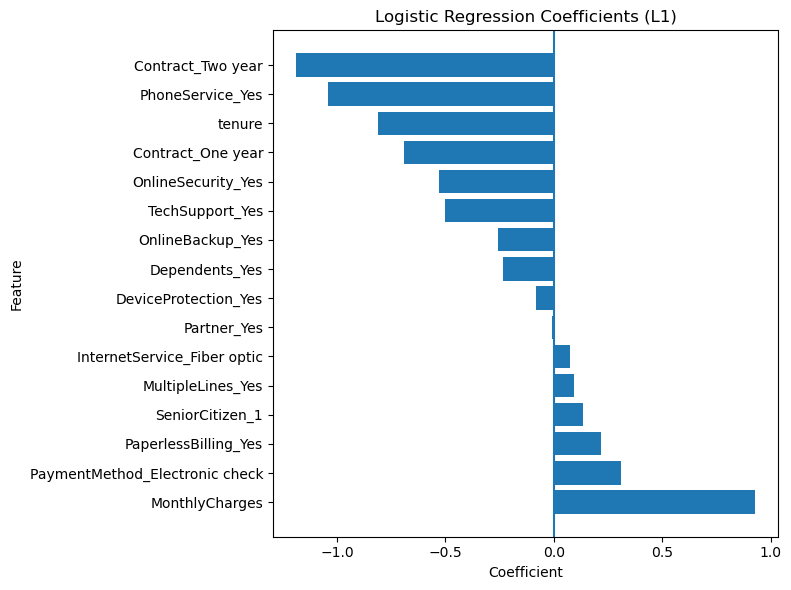

In [526]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(0)
plt.title("Logistic Regression Coefficients (L1)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


,feature,coefficient,odds_ratio
1,MonthlyCharges,0.928778,2.531415
24,PaymentMethod_Electronic check,0.312037,1.366206
4,PaperlessBilling_Yes,0.219749,1.245764
2,SeniorCitizen_1,0.136708,1.146493
6,MultipleLines_Yes,0.093361,1.097858


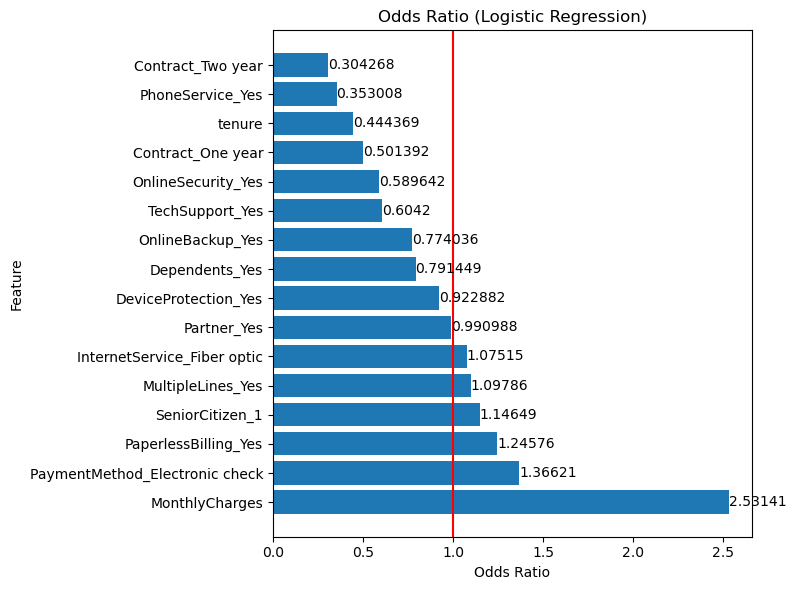

In [542]:
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
display(coef_df.head())
plt.figure(figsize=(8, 6))
bar = plt.barh(coef_df["feature"], coef_df["odds_ratio"])
plt.bar_label(bar, label_type='edge', color='black')
plt.axvline(1, color='red')
plt.title("Odds Ratio (Logistic Regression)")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [539]:
bar

<BarContainer object of 16 artists>

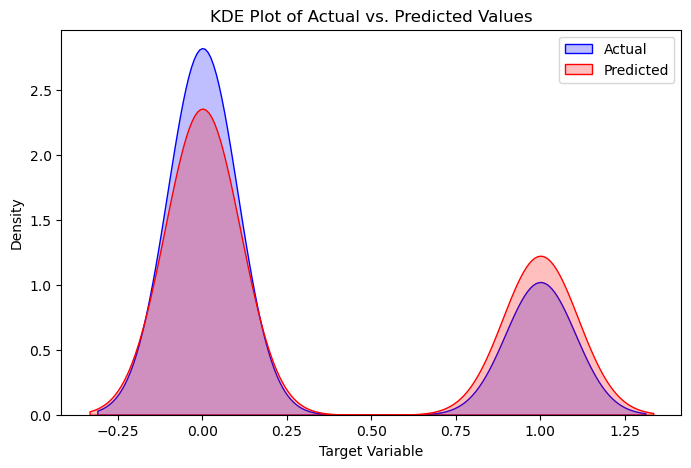

In [427]:
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test, label='Actual', fill=True, color='blue')
sns.kdeplot(y_pred, label='Predicted', fill=True, color='red')
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.title('KDE Plot of Actual vs. Predicted Values')
plt.legend()
plt.show()

In [401]:
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))
print("")
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1 Score:", f1_score(y_test, y_pred_opt))
print("Optimized ROC AUC:", roc_auc_score(y_test, y_proba_opt))
print("Optimized Log Loss:", log_loss(y_test, y_proba_opt))


Accuracy: 0.7704335465529495
Precision: 0.553014553014553
Recall: 0.7112299465240641
F1 Score: 0.6222222222222222
ROC AUC: 0.833615035383158
Log Loss: 0.42944813816514177

Optimized Accuracy: 0.8024164889836531
Precision: 0.6454545454545455
Recall: 0.56951871657754
F1 Score: 0.6051136363636364
Optimized ROC AUC: 0.8328566399718386
Optimized Log Loss: 0.43042109073540424


In [411]:
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))
print("")
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1 Score:", f1_score(y_test, y_pred_opt))
print("Optimized ROC AUC:", roc_auc_score(y_test, y_proba_opt))
print("Optimized Log Loss:", log_loss(y_test, y_proba_opt))


Accuracy: 0.7704335465529495
Precision: 0.553014553014553
Recall: 0.7112299465240641
F1 Score: 0.6222222222222222
ROC AUC: 0.833615035383158
Log Loss: 0.42944813816514177

Optimized Accuracy: 0.8024164889836531
Precision: 0.6454545454545455
Recall: 0.56951871657754
F1 Score: 0.6051136363636364
Optimized ROC AUC: 0.8328566399718386
Optimized Log Loss: 0.43042109073540424


In [412]:
l1_model = LogisticRegression(
    l1_ratio=0,
    solver="liblinear",
    C=3,
    max_iter=1000
)

l1_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", l1_model)
    ]
)

l1_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [413]:
accuracy_score(y_test, l1_pipeline.predict(X_test))

0.8038379530916845

In [414]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10, 50],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)


c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [418]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)


Best parameters: {'model__C': 10, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}


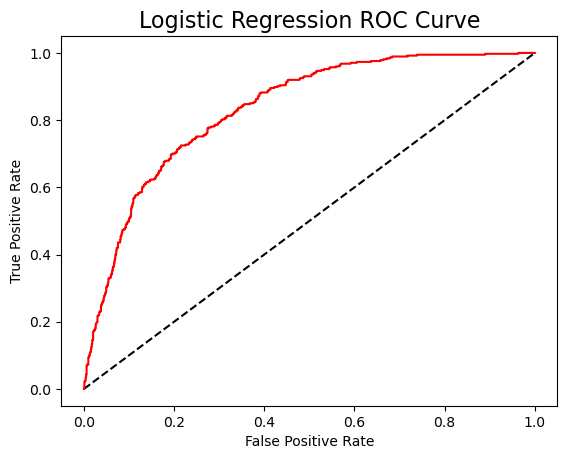

In [415]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_opt)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve',fontsize=16)
plt.show();

In [416]:
from sklearn.metrics import RocCurveDisplay

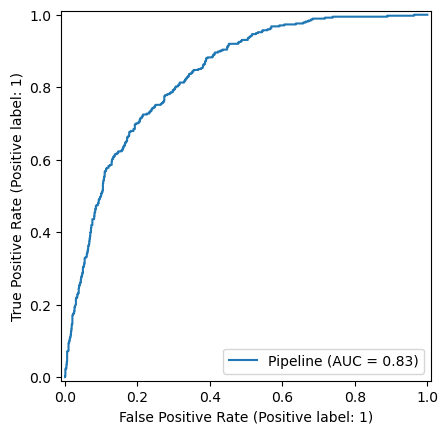

In [417]:
svc_disp = RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()